In [3]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("mymoviedb.csv", sep=None, engine="python", encoding="latin1")
print(df.head())
print(df.columns)
df.info()

  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller   
2          6.3                en                  

In [4]:
ndf=df.dropna()
ndf.drop_duplicates()
ndf.info()

<class 'pandas.DataFrame'>
Index: 9826 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9826 non-null   str    
 1   Title              9826 non-null   str    
 2   Overview           9826 non-null   str    
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   str    
 5   Vote_Average       9826 non-null   str    
 6   Original_Language  9826 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 767.7 KB


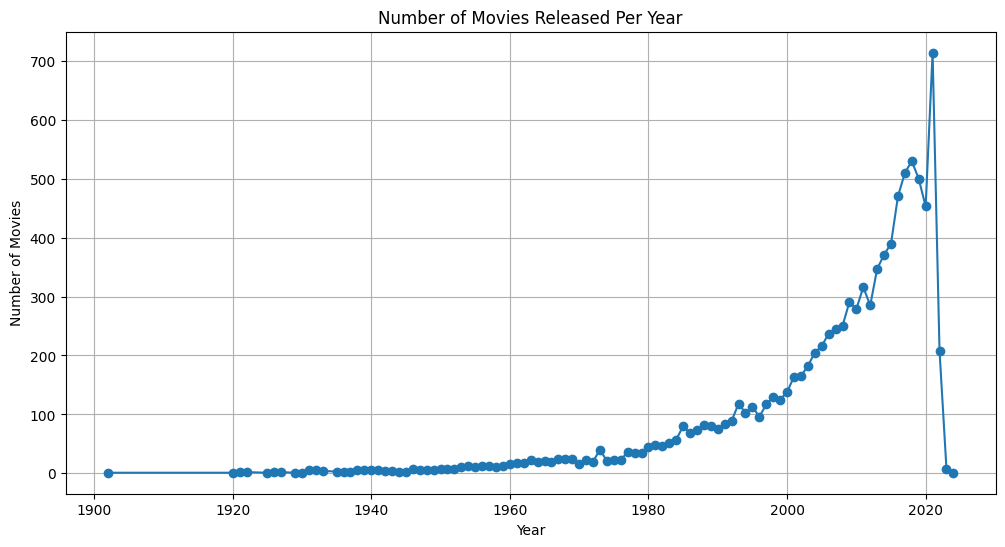

In [5]:
ndf['Release_Date']=pd.to_datetime(ndf['Release_Date'])
ndf['Year']= ndf['Release_Date'].dt.year
yearly_count = ndf['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
plt.plot(yearly_count.index, yearly_count.values, marker='o')
plt.title("Number of Movies Released Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.grid(True)
plt.savefig("yearly_trend.png")
plt.show()

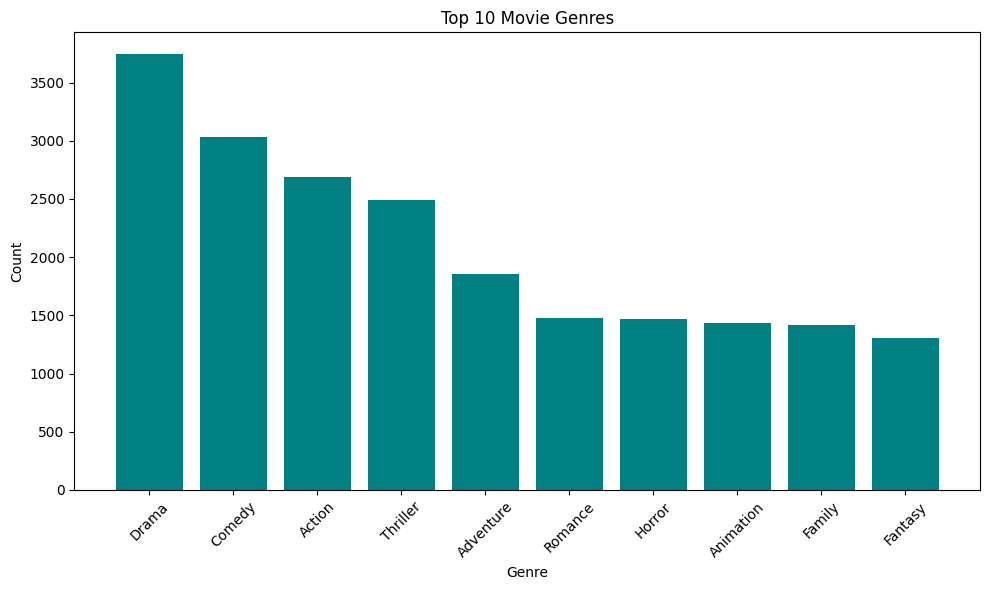

In [6]:
genre_split = ndf['Genre'].str.split(',', expand=True).stack()
genre_split = genre_split.str.strip()

top_genres = genre_split.value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_genres.index, top_genres.values, color='teal')
plt.title("Top 10 Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_genres.png")
plt.show()

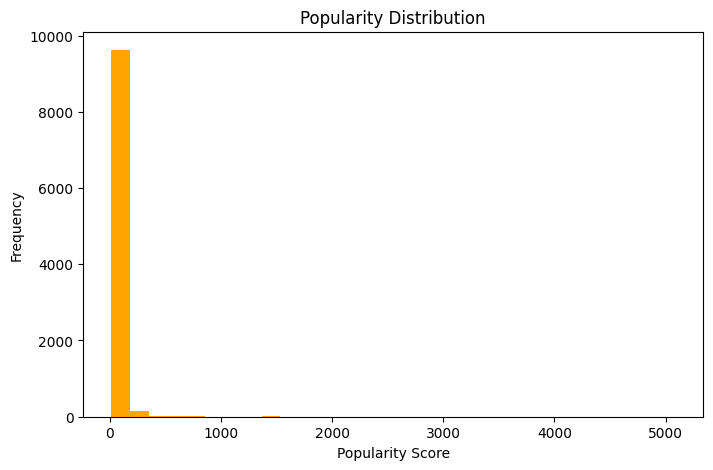

In [7]:
plt.figure(figsize=(8,5))
plt.hist(ndf['Popularity'], bins=30, color='orange')
plt.title("Popularity Distribution")
plt.xlabel("Popularity Score")
plt.ylabel("Frequency")
plt.savefig("popularity_distribution.png")
plt.show()

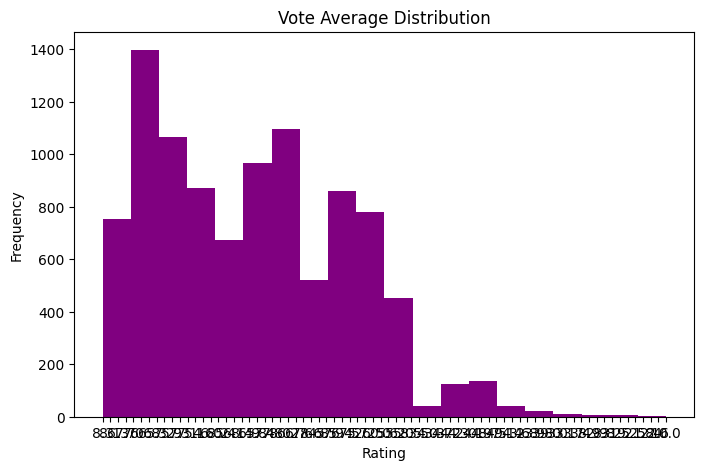

In [8]:
plt.figure(figsize=(8,5))
plt.hist(ndf['Vote_Average'].dropna(), bins=20, color='purple')
plt.title("Vote Average Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.savefig("rating_distribution.png")
plt.show()


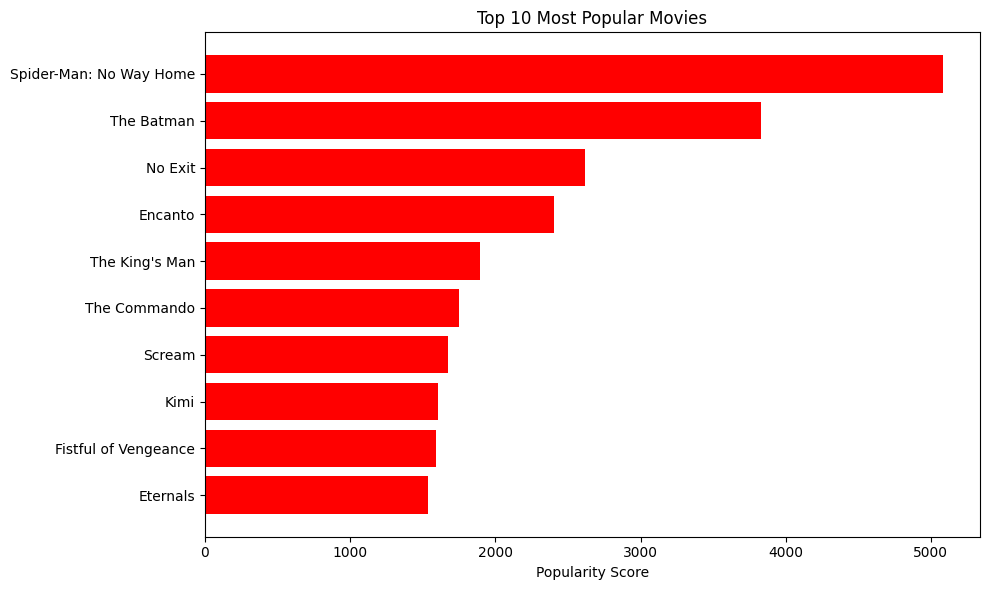

In [9]:
top_popular = ndf.sort_values(by='Popularity', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top_popular['Title'], top_popular['Popularity'], color='red')
plt.title("Top 10 Most Popular Movies")
plt.xlabel("Popularity Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("top_10_popular_movies.png")
plt.show()

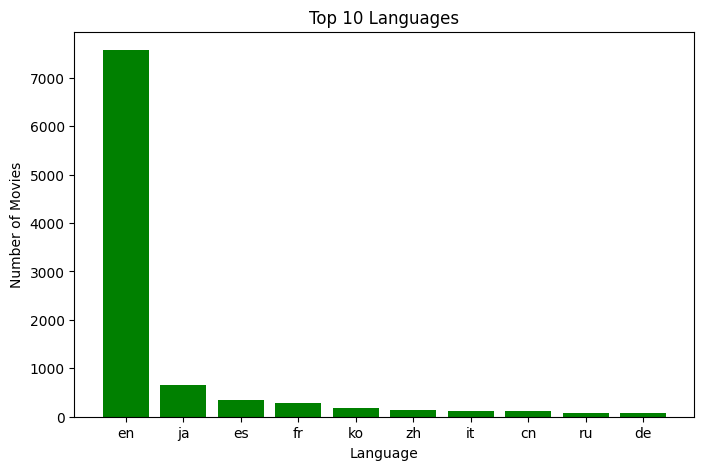

In [10]:
top_languages = ndf['Original_Language'].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(top_languages.index, top_languages.values, color='green')
plt.title("Top 10 Languages")
plt.xlabel("Language")
plt.ylabel("Number of Movies")
plt.savefig("top_languages.png")
plt.show()